# 1. Data Preprocessing Pipeline ✅

Complete pipeline for Instacart recommendation system.
Generates processed files for downstream notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
sns.set_style('whitegrid')

In [2]:
# Load raw data
print('Loading data...')
orders = pd.read_csv('../data/orders.csv')
order_products = pd.read_csv('../data/order_products__prior.csv')
products = pd.read_csv('../data/products.csv')

# Merge
df = order_products.merge(orders, on='order_id')
df = df.merge(products, on='product_id')

print(f'Merged dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(df.head())

Loading data...
Merged dataset: 32,434,489 rows, 13 columns
   order_id  product_id  add_to_cart_order  reordered  user_id eval_set  \
0         2       33120                  1          1   202279    prior   
1         2       28985                  2          1   202279    prior   
2         2        9327                  3          0   202279    prior   
3         2       45918                  4          1   202279    prior   
4         2       30035                  5          0   202279    prior   

   order_number  order_dow  order_hour_of_day  days_since_prior_order  \
0             3          5                  9                     8.0   
1             3          5                  9                     8.0   
2             3          5                  9                     8.0   
3             3          5                  9                     8.0   
4             3          5                  9                     8.0   

            product_name  aisle_id  department_id 

In [3]:
# Cleaning
df.dropna(subset=['user_id', 'product_id', 'product_name'], inplace=True)
df = df[df['user_id'] > 0]
df = df[df['eval_set'] == 'prior']  # Training data
df['reordered'] = df['reordered'].fillna(0).astype(int)

print(f'After cleaning: {df.shape[0]:,} rows')
print('Sample:\n', df.head(2))

After cleaning: 32,434,489 rows
Sample:
    order_id  product_id  add_to_cart_order  reordered  user_id eval_set  \
0         2       33120                  1          1   202279    prior   
1         2       28985                  2          1   202279    prior   

   order_number  order_dow  order_hour_of_day  days_since_prior_order  \
0             3          5                  9                     8.0   
1             3          5                  9                     8.0   

            product_name  aisle_id  department_id  
0     Organic Egg Whites        86             16  
1  Michigan Organic Kale        83              4  


In [4]:
# Create directories
os.makedirs('data/processed', exist_ok=True)
os.makedirs('results', exist_ok=True)
print('📁 Directories ready')

📁 Directories ready


In [5]:
# 1. User features for clustering (Notebook 3)
print('📊 Creating user features...')
user_features = df.groupby('user_id').agg({
    'order_id': 'nunique',
    'product_id': 'count',
    'reordered': ['count', 'mean']
}).round(3)
user_features.columns = ['num_orders', 'total_items', 'num_reorders', 'reorder_rate']
user_features = user_features.reset_index()

user_features.to_csv('data/processed/user_features.csv', index=False)
print(f'✅ Saved user_features.csv: {len(user_features)} users')

📊 Creating user features...
✅ Saved user_features.csv: 206209 users


In [6]:
# 2. Cleaned data for Apriori (Notebook 4)
print('🧹 Creating cleaned product data...')
df_clean = df[['user_id', 'order_id', 'product_id', 'product_name', 'department_id', 'aisle_id']].drop_duplicates(subset=['order_id', 'product_id'])

# Performance filter
top_products = df_clean['product_name'].value_counts().nlargest(1000).index
df_clean = df_clean[df_clean['product_name'].isin(top_products)]

df_clean.to_csv('data/processed/cleaned_user_products.csv', index=False)
print(f'✅ Saved cleaned_user_products.csv: {len(df_clean)} items, {df_clean["order_id"].nunique()} orders')

🧹 Creating cleaned product data...
✅ Saved cleaned_user_products.csv: 17515025 items, 2963012 orders


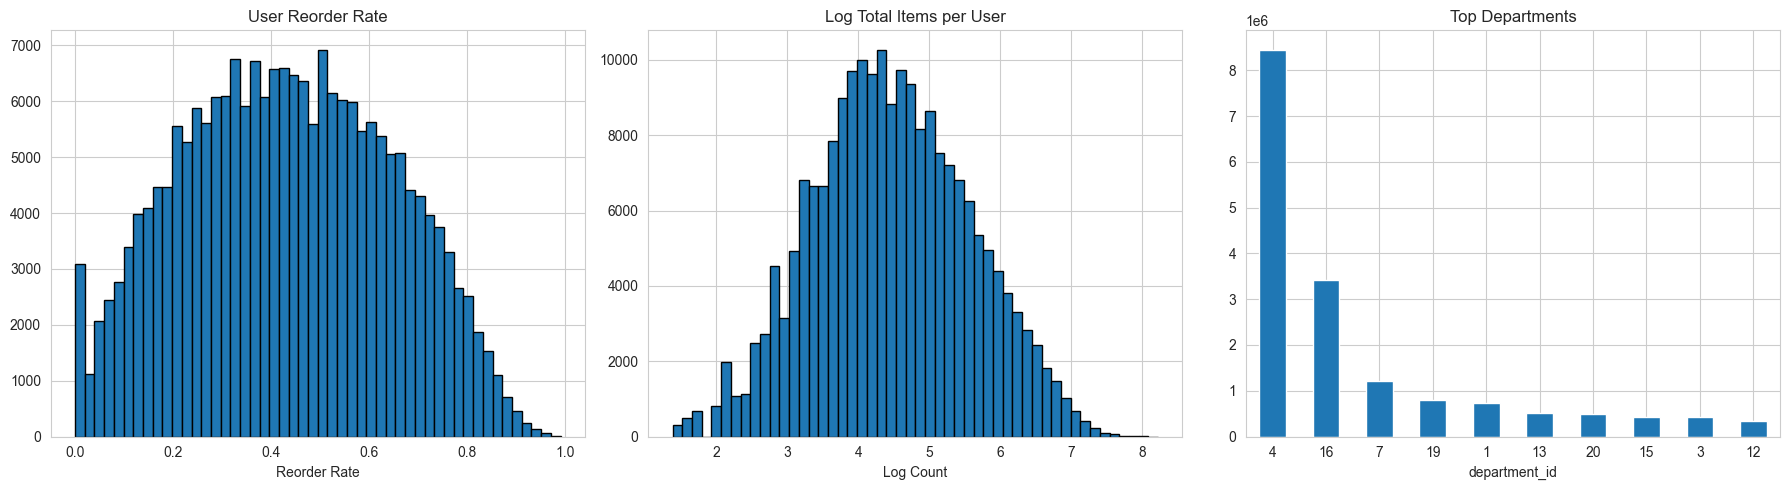

📈 Plots saved to results/preprocessing_summary.png

🚀 Phase 1 COMPLETE! Files ready for Notebooks 2-5


In [7]:
# Summary plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reorder rate
axes[0].hist(user_features['reorder_rate'], bins=50, edgecolor='black')
axes[0].set_title('User Reorder Rate')
axes[0].set_xlabel('Reorder Rate')

# Items per user
axes[1].hist(np.log1p(user_features['total_items']), bins=50, edgecolor='black')
axes[1].set_title('Log Total Items per User')
axes[1].set_xlabel('Log Count')

# Top departments
df_clean['department_id'].value_counts().head(10).plot(kind='bar', ax=axes[2])
axes[2].set_title('Top Departments')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('results/preprocessing_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('📈 Plots saved to results/preprocessing_summary.png')
print('\n🚀 Phase 1 COMPLETE! Files ready for Notebooks 2-5')

## Phase 1 Summary ✅

- **data/processed/user_features.csv**: User-level features for clustering
- **data/processed/cleaned_user_products.csv**: Cleaned transactions for Apriori
- **results/preprocessing_summary.png**: Summary visualizations

**Next**: Run `jupyter notebook notebooks/2_eda_analysis.ipynb`